In [ ]:
# =============================================================================
# SECTION 1: Upload your CSV
# Paste this into its own Colab cell and run it first.
# =============================================================================
from google.colab import files
uploaded = files.upload()  # select your attribution_data.csv when prompted


Saving attribution_data.csv to attribution_data.csv


In [ ]:

# =============================================================================
# SECTION 2: Load, clean, and build journeys
# Paste into the next cell.
# =============================================================================
import pandas as pd

FILENAME = "attribution_data.csv"  # change this if your file has a different name

df = pd.read_csv(FILENAME)
df = df.dropna(subset=["cookie", "channel", "time"]).copy()
df["time"] = pd.to_datetime(df["time"], format="ISO8601")
df = df.sort_values(["cookie", "time"]).reset_index(drop=True)

channels = sorted(df["channel"].dropna().unique().tolist())

journeys = (
    df.groupby("cookie", group_keys=False)
    .apply(
        lambda g: pd.Series({
            "path": list(g.sort_values("time")["channel"]),
            "converted": int(g["conversion"].sum() > 0),
            "conversion_value": g["conversion_value"].sum(),
            "n_touchpoints": len(g),
        }),
        include_groups=False,
    )
    .reset_index()
)

n_conversions = journeys["converted"].sum()
print(f"Touchpoint rows: {len(df):,}")
print(f"Users: {len(journeys):,} | Conversions: {n_conversions:,} ({journeys['converted'].mean():.2%})")
print(f"Channels: {channels}")

Touchpoint rows: 586,737
Users: 240,108 | Conversions: 17,639 (7.35%)
Channels: ['Facebook', 'Instagram', 'Online Display', 'Online Video', 'Paid Search']


In [ ]:

# =============================================================================
# SECTION 3: Heuristic (rule-based) models
# Paste into the next cell.
# =============================================================================
from collections import defaultdict

def first_touch(paths):
    credit = defaultdict(float)
    for path in paths:
        credit[path[0]] += 1
    return dict(credit)

def last_touch(paths):
    credit = defaultdict(float)
    for path in paths:
        credit[path[-1]] += 1
    return dict(credit)

def linear(paths):
    credit = defaultdict(float)
    for path in paths:
        weight = 1 / len(path)
        for ch in path:
            credit[ch] += weight
    return dict(credit)

def u_shaped(paths):
    credit = defaultdict(float)
    for path in paths:
        n = len(path)
        if n == 1:
            credit[path[0]] += 1
        elif n == 2:
            credit[path[0]] += 0.5
            credit[path[1]] += 0.5
        else:
            credit[path[0]] += 0.4
            credit[path[-1]] += 0.4
            middle_weight = 0.2 / (n - 2)
            for ch in path[1:-1]:
                credit[ch] += middle_weight
    return dict(credit)

def time_decay(paths, half_life=1.0):
    credit = defaultdict(float)
    for path in paths:
        n = len(path)
        weights = [2 ** (-(n - 1 - i) / half_life) for i in range(n)]
        total = sum(weights)
        for ch, w in zip(path, weights):
            credit[ch] += w / total
    return dict(credit)

converting_paths = journeys[journeys["converted"] == 1]["path"].tolist()

heuristic_results = pd.DataFrame({
    "First Touch": first_touch(converting_paths),
    "Last Touch": last_touch(converting_paths),
    "Linear": linear(converting_paths),
    "U-Shaped": u_shaped(converting_paths),
    "Time Decay": time_decay(converting_paths),
}).fillna(0).round(1)

print(heuristic_results)
print("\nAs %:")
print((heuristic_results / heuristic_results.sum() * 100).round(1))

                First Touch  Last Touch  Linear  U-Shaped  Time Decay
Paid Search          4757.0      4547.0  4681.2    4664.3      4611.5
Facebook             5177.0      5301.0  5218.9    5228.2      5257.9
Online Video         3216.0      3408.0  3349.4    3323.6      3384.7
Instagram            2329.0      2244.0  2265.2    2281.0      2258.8
Online Display       2160.0      2139.0  2124.3    2141.9      2126.1

As %:
                First Touch  Last Touch  Linear  U-Shaped  Time Decay
Paid Search            27.0        25.8    26.5      26.4        26.1
Facebook               29.3        30.1    29.6      29.6        29.8
Online Video           18.2        19.3    19.0      18.8        19.2
Instagram              13.2        12.7    12.8      12.9        12.8
Online Display         12.2        12.1    12.0      12.1        12.1


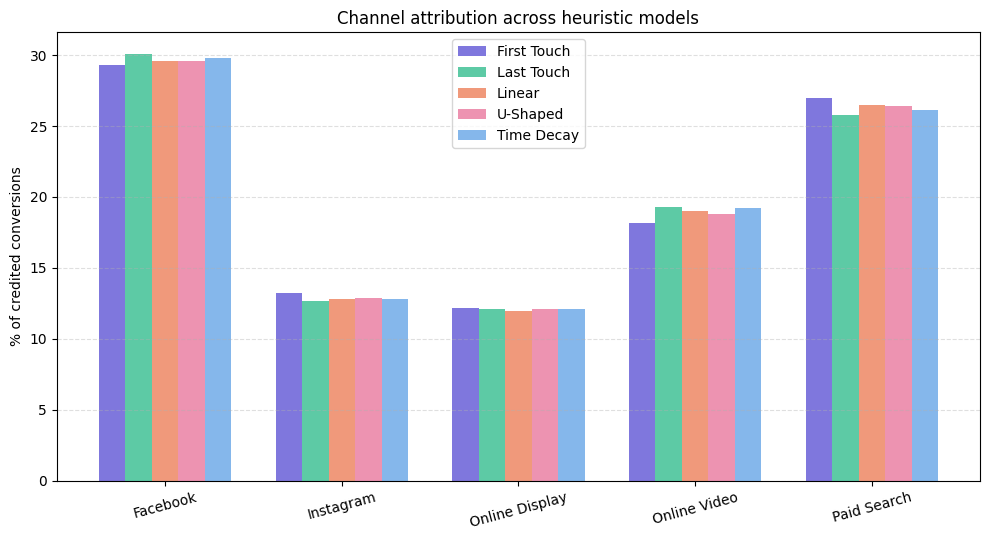

In [ ]:
# =============================================================================
# SECTION 3b: Chart for heuristic model comparison
# Paste into the next cell (after Section 3).
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

heuristic_pct = (heuristic_results / heuristic_results.sum() * 100).round(1)

models = heuristic_pct.columns.tolist()
x = np.arange(len(channels))
width = 0.15

colors = ["#7F77DD", "#5DCAA5", "#F0997B", "#ED93B1", "#85B7EB"]

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, model_name in enumerate(models):
    offset = (i - len(models) / 2) * width + width / 2
    ax.bar(x + offset, heuristic_pct.reindex(channels)[model_name], width,
           label=model_name, color=colors[i])

ax.set_ylabel("% of credited conversions")
ax.set_title("Channel attribution across heuristic models")
ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=15)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

In [ ]:

# =============================================================================
# SECTION 4: Markov chain removal-effect model
# Paste into the next cell.
# =============================================================================
from copy import deepcopy

def build_markov_paths(journeys_df):
    paths = []
    for _, row in journeys_df.iterrows():
        path = ["Start"] + row["path"]
        path.append("Conversion" if row["converted"] == 1 else "Null")
        paths.append(path)
    return paths

def build_transition_probs(paths):
    transition_counts = defaultdict(lambda: defaultdict(int))
    for path in paths:
        for i in range(len(path) - 1):
            transition_counts[path[i]][path[i + 1]] += 1
    transition_probs = {}
    for state, next_states in transition_counts.items():
        total = sum(next_states.values())
        transition_probs[state] = {k: v / total for k, v in next_states.items()}
    return transition_probs

def conversion_probability(trans_probs, start="Start", removed_state=None, max_steps=100):
    probs = deepcopy(trans_probs)
    if removed_state:
        for state in probs:
            if removed_state in probs[state]:
                probs[state]["Null"] = probs[state].get("Null", 0) + probs[state][removed_state]
                del probs[state][removed_state]
        probs.pop(removed_state, None)

    state_prob = defaultdict(float)
    state_prob[start] = 1.0
    total_conversion_prob = 0.0
    for _ in range(max_steps):
        new_state_prob = defaultdict(float)
        for state, p in state_prob.items():
            if state in ("Conversion", "Null") or state not in probs:
                continue
            for next_state, trans_p in probs[state].items():
                if next_state == "Conversion":
                    total_conversion_prob += p * trans_p
                elif next_state != "Null":
                    new_state_prob[next_state] += p * trans_p
        state_prob = new_state_prob
        if sum(state_prob.values()) < 1e-10:
            break
    return total_conversion_prob

all_paths = build_markov_paths(journeys)
trans_probs = build_transition_probs(all_paths)
baseline_prob = conversion_probability(trans_probs)
print(f"Baseline conversion probability: {baseline_prob:.4f}")

removal_effects = {}
for ch in channels:
    prob_without = conversion_probability(trans_probs, removed_state=ch)
    removal_effects[ch] = (baseline_prob - prob_without) / baseline_prob

total_effect = sum(removal_effects.values())
markov_credit = pd.Series({
    ch: (effect / total_effect) * n_conversions for ch, effect in removal_effects.items()
}).round(1)

print("\nRemoval effects:")
print(pd.Series(removal_effects).round(4))
print("\nMarkov credited conversions:")
print(markov_credit)
print("\nAs %:")
print((markov_credit / markov_credit.sum() * 100).round(1))


Baseline conversion probability: 0.0735

Removal effects:
Facebook          0.4139
Instagram         0.2382
Online Display    0.1669
Online Video      0.2294
Paid Search       0.3414
dtype: float64

Markov credited conversions:
Facebook          5253.5
Instagram         3023.1
Online Display    2118.2
Online Video      2911.4
Paid Search       4332.8
dtype: float64

As %:
Facebook          29.8
Instagram         17.1
Online Display    12.0
Online Video      16.5
Paid Search       24.6
dtype: float64


/tmp/ipykernel_2418/3704825105.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(channels, rotation=20)
/tmp/ipykernel_2418/3704825105.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(channels, rotation=20)


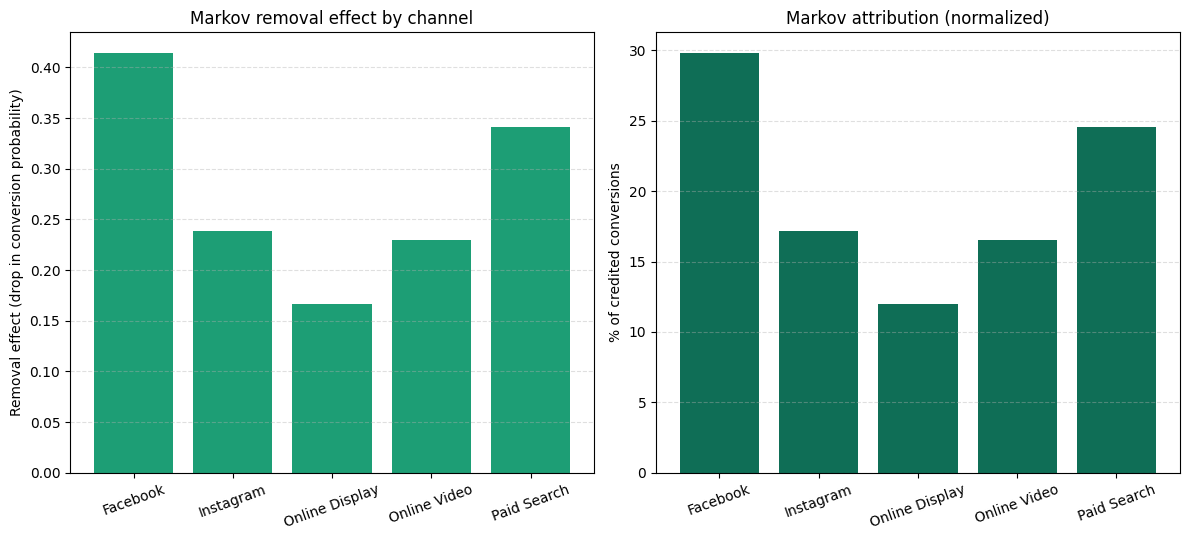

In [ ]:
# =============================================================================
# SECTION 4b: Chart for Markov chain removal-effect results
# Paste into the next cell (after Section 4).
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

removal_series = pd.Series(removal_effects).reindex(channels)
markov_pct_series = (markov_credit / markov_credit.sum() * 100).reindex(channels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].bar(channels, removal_series, color="#1D9E75")
axes[0].set_ylabel("Removal effect (drop in conversion probability)")
axes[0].set_title("Markov removal effect by channel")
axes[0].set_xticklabels(channels, rotation=20)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].bar(channels, markov_pct_series, color="#0F6E56")
axes[1].set_ylabel("% of credited conversions")
axes[1].set_title("Markov attribution (normalized)")
axes[1].set_xticklabels(channels, rotation=20)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()

In [ ]:

# =============================================================================
# SECTION 5: Shapley value model (occurrence-weighted — avoids the negative-
# value bug that the naive equal-weighted version can produce on sparse data)
# Paste into the next cell.
# =============================================================================
import math
from itertools import combinations

journeys["channel_set"] = journeys["path"].apply(lambda p: frozenset(p))
subset_stats = journeys.groupby("channel_set").agg(
    total=("converted", "count"), conversions=("converted", "sum")
)
subset_stats["conv_rate"] = subset_stats["conversions"] / subset_stats["total"]
value_lookup = subset_stats["conv_rate"].to_dict()
count_lookup = subset_stats["total"].to_dict()

def v(subset):
    return value_lookup.get(frozenset(subset), 0.0)

def n_obs(subset):
    return count_lookup.get(frozenset(subset), 0)

n = len(channels)
shapley_values = {}
for target in channels:
    others = [c for c in channels if c != target]
    weighted_total, weight_sum = 0.0, 0.0
    for r in range(len(others) + 1):
        for subset in combinations(others, r):
            s = len(subset)
            combinatorial_weight = (math.factorial(s) * math.factorial(n - s - 1)) / math.factorial(n)
            marginal = v(set(subset) | {target}) - v(set(subset))
            obs_weight = n_obs(subset) + n_obs(set(subset) | {target})
            w = combinatorial_weight * obs_weight
            weighted_total += w * marginal
            weight_sum += w
    shapley_values[target] = weighted_total / weight_sum if weight_sum > 0 else 0.0

shapley_series = pd.Series(shapley_values)
shapley_pct = (shapley_series / shapley_series.sum() * 100).round(1)
print("Raw Shapley values:")
print(shapley_series)
print("\nAs %:")
print(shapley_pct)

Raw Shapley values:
Facebook          0.043388
Instagram         0.034142
Online Display    0.027404
Online Video      0.056531
Paid Search       0.039477
dtype: float64

As %:
Facebook          21.6
Instagram         17.0
Online Display    13.6
Online Video      28.1
Paid Search       19.6
dtype: float64


/tmp/ipykernel_2418/1521279266.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(channels, rotation=20)
/tmp/ipykernel_2418/1521279266.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(channels, rotation=20)


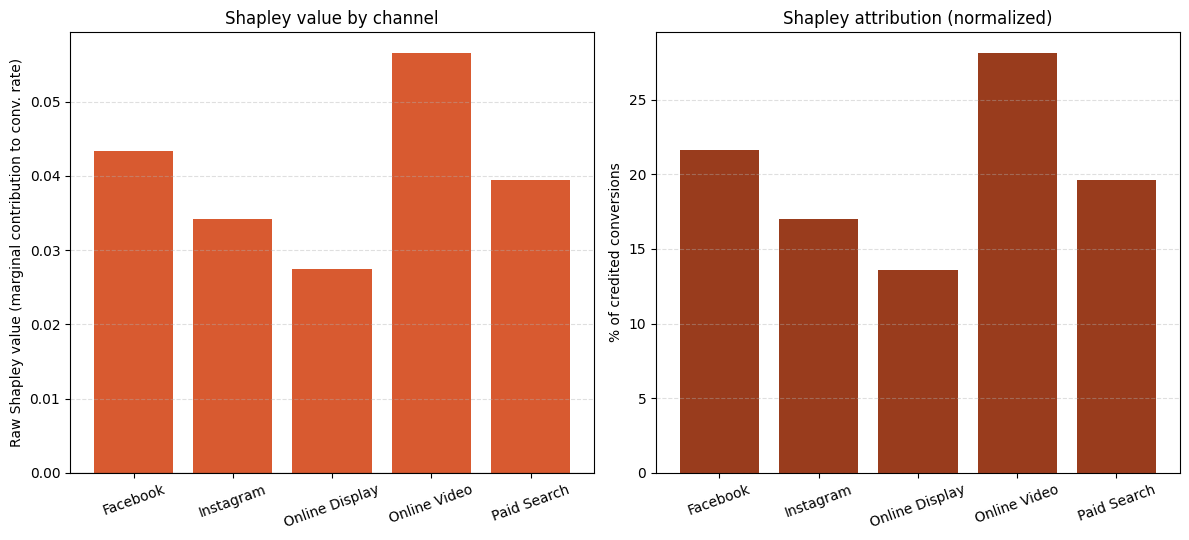

In [ ]:
# =============================================================================
# SECTION 5b: Chart for Shapley value results
# Paste into the next cell (after Section 5).
# =============================================================================
import matplotlib.pyplot as plt

shapley_raw_series = shapley_series.reindex(channels)
shapley_pct_series = shapley_pct.reindex(channels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].bar(channels, shapley_raw_series, color="#D85A30")
axes[0].set_ylabel("Raw Shapley value (marginal contribution to conv. rate)")
axes[0].set_title("Shapley value by channel")
axes[0].set_xticklabels(channels, rotation=20)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].bar(channels, shapley_pct_series, color="#993C1D")
axes[1].set_ylabel("% of credited conversions")
axes[1].set_title("Shapley attribution (normalized)")
axes[1].set_xticklabels(channels, rotation=20)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()

In [ ]:

# =============================================================================
# SECTION 6: Logistic regression (ML) model
# Paste into the next cell.
# =============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

def featurize(path):
    feats = {}
    for ch in channels:
        feats[f"{ch}_count"] = path.count(ch)
        feats[f"{ch}_present"] = int(ch in path)
    feats["total_touchpoints"] = len(path)
    feats["unique_channels"] = len(set(path))
    feats["first_channel"] = path[0]
    feats["last_channel"] = path[-1]
    return feats

feature_rows = journeys["path"].apply(featurize).apply(pd.Series)
feature_rows = pd.get_dummies(feature_rows, columns=["first_channel", "last_channel"])
feature_rows = feature_rows.apply(pd.to_numeric, errors="coerce").fillna(0)

X = feature_rows.values
y = journeys["converted"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"Test AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(classification_report(y_test, y_pred, target_names=["Not converted", "Converted"]))

Test AUC: 0.590
               precision    recall  f1-score   support

Not converted       0.94      0.69      0.80     44494
    Converted       0.10      0.45      0.17      3528

     accuracy                           0.67     48022
    macro avg       0.52      0.57      0.48     48022
 weighted avg       0.88      0.67      0.75     48022



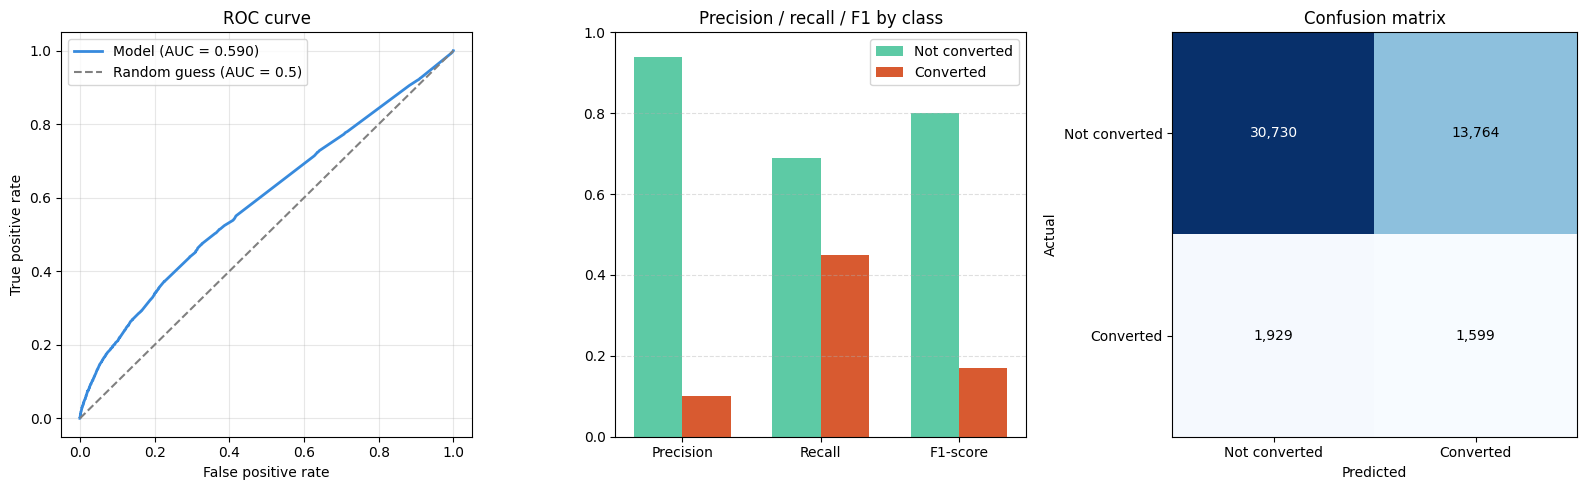

In [ ]:
# =============================================================================
# SECTION 6b: Chart for logistic regression results (ROC curve,
# precision/recall/F1 by class, and confusion matrix)
# Paste into the next cell (after Section 6).
# =============================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

axes[0].plot(fpr, tpr, color="#378ADD", linewidth=2, label=f"Model (AUC = {auc_score:.3f})")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess (AUC = 0.5)")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Panel 2: Precision / recall / F1 by class ---
metrics = {
    "Not converted": [0.94, 0.69, 0.80],
    "Converted":     [0.10, 0.45, 0.17],
}
labels = ["Precision", "Recall", "F1-score"]
x = np.arange(len(labels))
width = 0.35

axes[1].bar(x - width/2, metrics["Not converted"], width, label="Not converted", color="#5DCAA5")
axes[1].bar(x + width/2, metrics["Converted"], width, label="Converted", color="#D85A30")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 1)
axes[1].set_title("Precision / recall / F1 by class")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

# --- Panel 3: Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(["Not converted", "Converted"])
axes[2].set_yticklabels(["Not converted", "Converted"])
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_title("Confusion matrix")

for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.tight_layout()
plt.show()

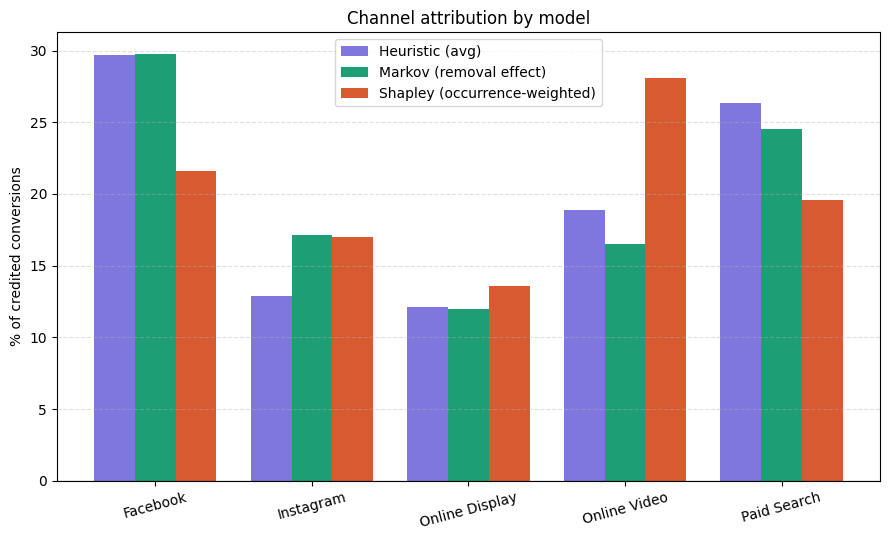

In [ ]:

# =============================================================================
# SECTION 7: Comparison chart across all models
# Paste into the next cell.
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

heuristic_pct = (heuristic_results / heuristic_results.sum() * 100).round(1)
heuristic_avg = heuristic_pct.mean(axis=1)
markov_pct = (markov_credit / markov_credit.sum() * 100)

x = np.arange(len(channels))
width = 0.26

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x - width, heuristic_avg.reindex(channels), width, label="Heuristic (avg)", color="#7F77DD")
ax.bar(x, markov_pct.reindex(channels), width, label="Markov (removal effect)", color="#1D9E75")
ax.bar(x + width, shapley_pct.reindex(channels), width, label="Shapley (occurrence-weighted)", color="#D85A30")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("% of credited conversions")
ax.set_title("Channel attribution by model")
ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=15)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()